In [3]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("catherinerasgaitis/mxmh-survey-results")

print("Path to dataset files:", path)



100%|██████████| 22.4k/22.4k [00:00<00:00, 27.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/catherinerasgaitis/mxmh-survey-results/versions/1


In [4]:
import os

os.listdir(path)
import pandas as pd

df = pd.read_csv(os.path.join(path, "mxmh_survey_results.csv"))
df.head()

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


In [6]:
df

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,10/30/2022 14:37:28,17.0,Spotify,2.0,Yes,Yes,No,Rock,Yes,Yes,...,Never,Rarely,Very frequently,Never,7.0,6.0,0.0,9.0,Improve,I understand.
732,11/1/2022 22:26:42,18.0,Spotify,1.0,Yes,Yes,No,Pop,Yes,Yes,...,Never,Never,Sometimes,Sometimes,3.0,2.0,2.0,5.0,Improve,I understand.
733,11/3/2022 23:24:38,19.0,Other streaming service,6.0,Yes,No,Yes,Rap,Yes,No,...,Sometimes,Sometimes,Rarely,Rarely,2.0,2.0,2.0,2.0,Improve,I understand.
734,11/4/2022 17:31:47,19.0,Spotify,5.0,Yes,Yes,No,Classical,No,No,...,Never,Never,Never,Sometimes,2.0,3.0,2.0,1.0,Improve,I understand.


In [16]:
df.groupby(by=["Fav genre"]).mean(numeric_only=True)["Age"]

,Age
Fav genre,
Classical,26.226415
Country,25.360000
EDM,22.054054
Folk,25.800000
Gospel,55.666667
Hip hop,23.441176
Jazz,25.450000
K pop,18.423077
Latin,17.666667


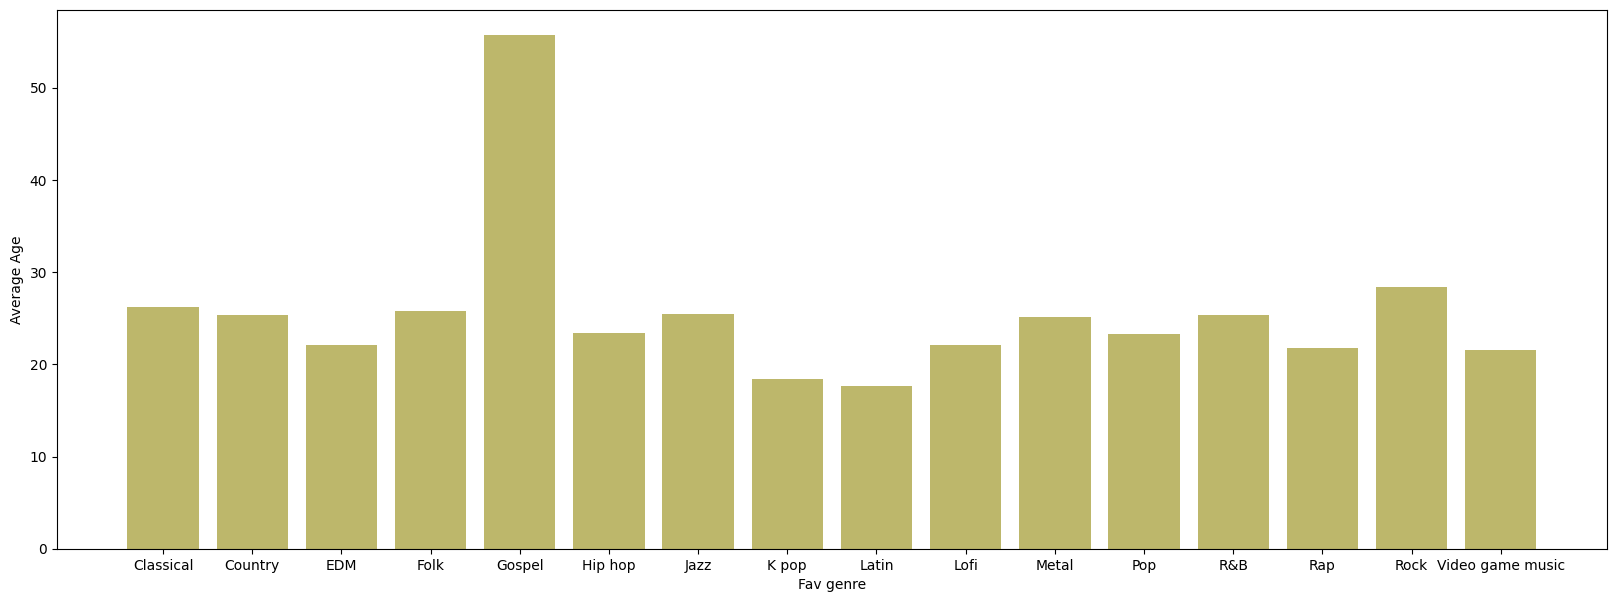

In [15]:

import matplotlib.pyplot as plt
#plt.hist(path["Age"]["Favgenre"])
# en cox hansi yas araligi janra qulaq asir
plt.figure(figsize=(20,7))
plt.xlabel("Fav genre")
plt.ylabel("Average Age")
plt.bar((df.groupby(by=["Fav genre"]).mean(numeric_only=True)["Age"]).index,(df.groupby(by=["Fav genre"]).mean(numeric_only=True)["Age"]).values,color="darkkhaki" )

plt.show()




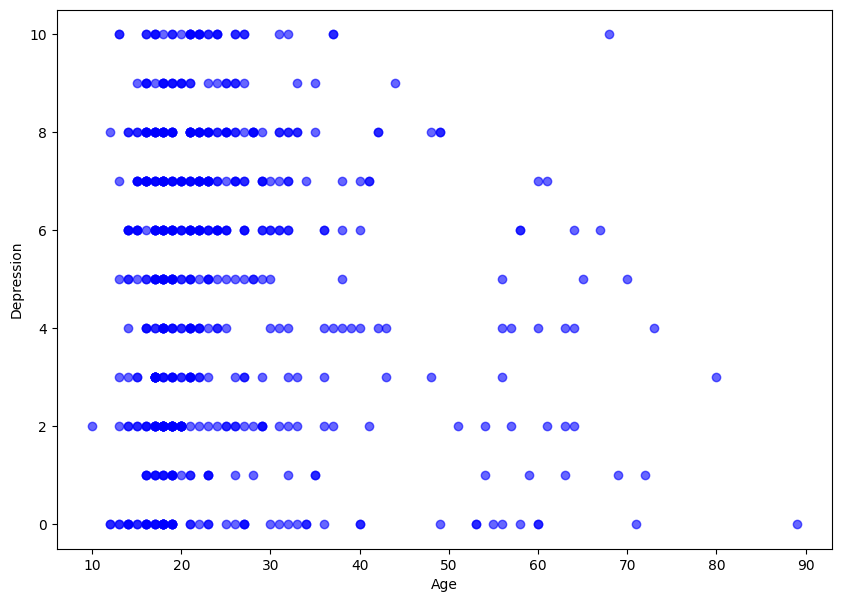

In [25]:
# isleyende dinleyenler  icinden age ile depressia asililigi
import numpy as np
plt.figure(figsize=(10,7))
plt.xlabel("Age")
plt.ylabel("Depression")
Age_s=df.loc[df["While working"]=="Yes","Age"]
Depression_s = df.loc[df["While working"]=="Yes", "Depression"]
plt.scatter(Age_s,Depression_s,alpha=0.6, color='blue')
plt.show()


In [18]:
df.groupby(by=["Primary streaming service"]).mean(numeric_only=True)["Age"]

,Age
Primary streaming service,
Apple Music,24.215686
I do not use a streaming service.,31.605634
Other streaming service,30.220000
Pandora,50.181818
Spotify,22.702407
YouTube Music,27.542553


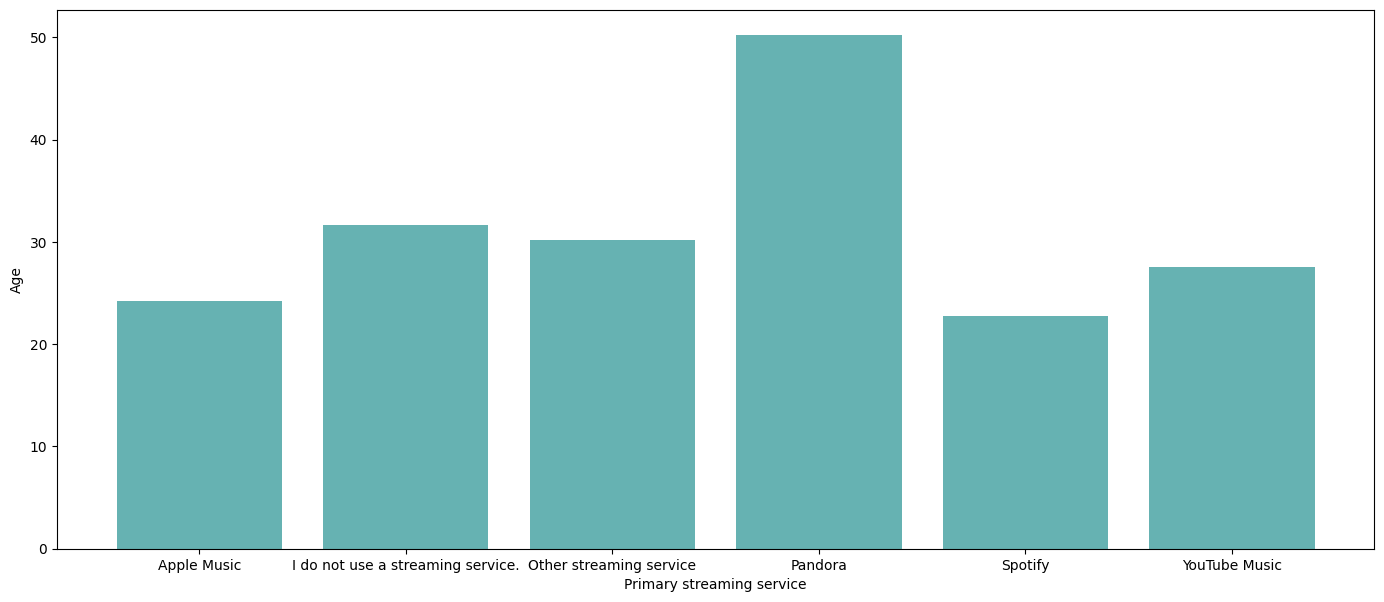

In [26]:
# music toolardan sitifade etme yas ortlamasi
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(17,7))
plt.xlabel("Primary streaming service")
plt.ylabel("Age")
plt.bar(df.groupby(by=["Primary streaming service"]).mean(numeric_only=True)["Age"].index,df.groupby(by=["Primary streaming service"]).mean(numeric_only=True)["Age"].values,alpha=0.6, color='teal')
plt.show()


In [30]:
df["Music effects"].unique()

array([nan, 'No effect', 'Improve', 'Worsen'], dtype=object)

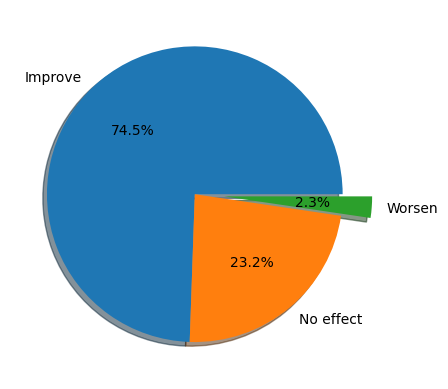

In [48]:
#music effect faiz nisbeti
plt.pie(df["Music effects"].value_counts().values,labels=df["Music effects"].value_counts().index,autopct="%.1f%%",shadow=True,explode=[0,0,0.2])
plt.show()

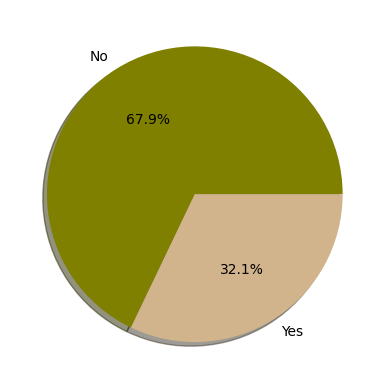

In [58]:
colors = ["olive", "tan"]

plt.pie(df["Instrumentalist"].value_counts().values,labels=df["Instrumentalist"].value_counts().index,autopct="%.1f%%",shadow=True,colors=colors)
plt.show()

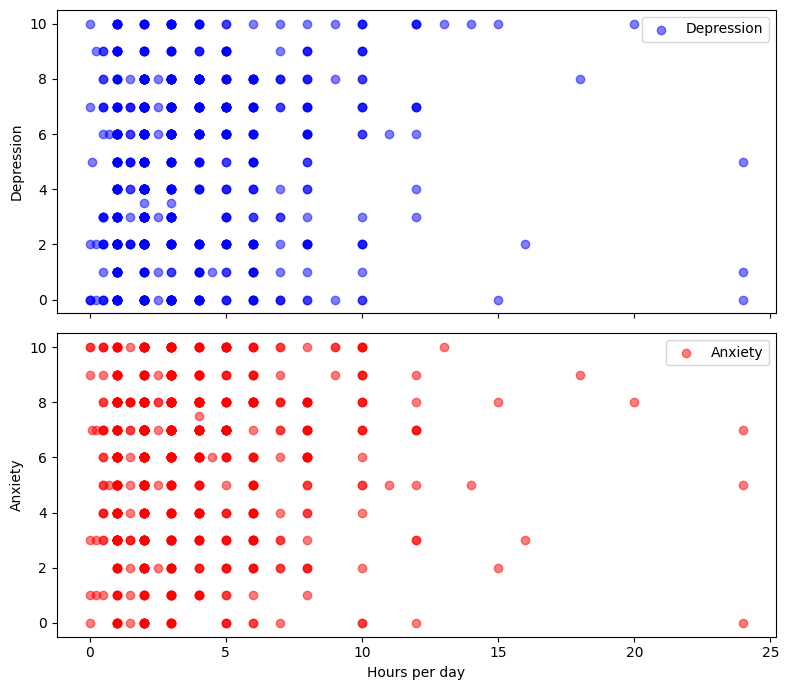

In [81]:
#depresiya ve anxietynin satdan asililig

import pandas as pd
import matplotlib.pyplot as plt

fig,ax=plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(8,7))

#plt.figure(figsize=(10,6))
ax[0].scatter( df["Hours per day"],df["Depression"],alpha=0.5,color='blue',label="Depression")
ax[1].scatter( df["Hours per day"],df["Anxiety"],  alpha=0.5, color='red',label="Anxiety")
#plt.xlabel("Hours per day")
ax[0].set_ylabel("Depression")
ax[0].legend()
ax[1].set_ylabel("Anxiety")
ax[1].legend()
ax[1].set_xlabel("Hours per day")
plt.tight_layout()
plt.show()
